# Movie Recommendation System using Matrix Factorization


---
# SCENARIO 1 – Matrix Factorization using SVD

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

print("Name: Mohamed Aashik S \nRoll No: 24BAD072\n")

Name: Mohamed Aashik S 
Roll No: 24BAD072



In [ ]:
movies  = pd.read_csv("C:\\Users\\Mohamed Aashik\\OneDrive - Kumaraguru College of Technology\\Assignment\\ML\\ML Repo\\EX 10-Recommendation Systems using Matrix Fac\\Dataset\\movies.csv")
ratings = pd.read_csv("C:\\Users\\Mohamed Aashik\\OneDrive - Kumaraguru College of Technology\\Assignment\\ML\\ML Repo\\EX 10-Recommendation Systems using Matrix Fac\\Dataset\\ratings.csv")

print("Movies shape  :", movies.shape)
print("Ratings shape :", ratings.shape)
print()
print("Movies sample:")
display(movies.head())
print("Ratings sample:")
display(ratings.head())

Movies shape  : (10329, 3)
Ratings shape : (105339, 4)

Movies sample:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Ratings sample:


,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [ ]:
print("=== Ratings Info ===")
ratings.info()
print("\nMissing values in ratings:", ratings.isnull().sum().sum())
print("Unique users  :", ratings['userId'].nunique())
print("Unique movies :", ratings['movieId'].nunique())
print("Rating range  :", ratings['rating'].min(), "–", ratings['rating'].max())
print("\nRating distribution:")
display(ratings['rating'].value_counts().sort_index())

ratings = ratings.drop(columns=['timestamp'])

min_ratings_per_user  = 20
min_ratings_per_movie = 10

user_counts  = ratings['userId'].value_counts()
movie_counts = ratings['movieId'].value_counts()

ratings = ratings[
    ratings['userId'].isin(user_counts[user_counts  >= min_ratings_per_user].index) &
    ratings['movieId'].isin(movie_counts[movie_counts >= min_ratings_per_movie].index)
]

print(f"\nAfter filtering – Users: {ratings['userId'].nunique()}, Movies: {ratings['movieId'].nunique()}, Rows: {len(ratings)}")

=== Ratings Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     105339 non-null  int64  
 1   movieId    105339 non-null  int64  
 2   rating     105339 non-null  float64
 3   timestamp  105339 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.2 MB

Missing values in ratings: 0
Unique users  : 668
Unique movies : 10325
Rating range  : 0.5 – 5.0

Rating distribution:


rating
0.5     1198
1.0     3258
1.5     1567
2.0     7943
2.5     5484
3.0    21729
3.5    12237
4.0    28880
4.5     8187
5.0    14856
Name: count, dtype: int64


After filtering – Users: 668, Movies: 2315, Rows: 84049


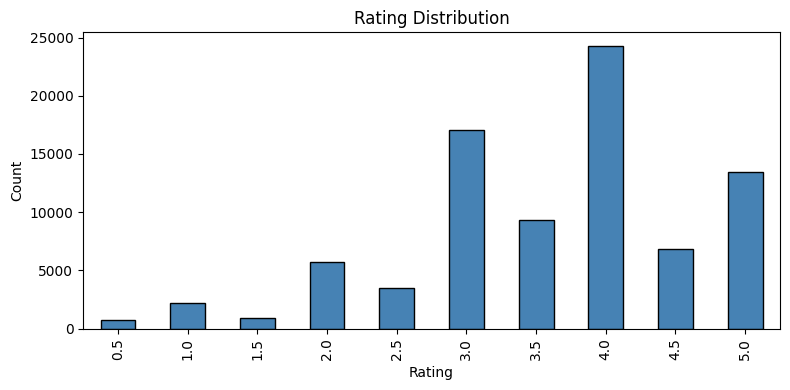

In [6]:
# Rating distribution plot
plt.figure(figsize=(8,4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
user_item_matrix = ratings.pivot_table(
    index='userId', columns='movieId', values='rating'
)

print("User-Item matrix shape:", user_item_matrix.shape)
sparsity = 1 - (user_item_matrix.count().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))
print(f"Sparsity: {sparsity:.2%}")
display(user_item_matrix.iloc[:5, :8])

User-Item matrix shape: (668, 2315)
Sparsity: 94.56%


movieId,1,2,3,4,5,6,7,9
userId,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,NaN,2.0,NaN,3.0,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,3.0,NaN,3.0,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
matrix_filled = user_item_matrix.fillna(0)

user_means = user_item_matrix.mean(axis=1) 

matrix_centered = user_item_matrix.sub(user_means, axis=0).fillna(0)

print("Mean-centered matrix (sample):")
display(matrix_centered.iloc[:5, :8].round(2))

Mean-centered matrix (sample):


movieId,1,2,3,4,5,6,7,9
userId,,,,,,,,
1,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0
2,1.1,0.0,-1.9,0.0,-0.90,0.0,0.00,0.0
3,0.0,0.0,0.0,0.0,-0.79,0.0,-0.79,0.0
4,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0
5,1.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0


In [ ]:
R = matrix_centered.values  
K = 50 
svd = TruncatedSVD(n_components=K, random_state=42)
U_k = svd.fit_transform(R)       
Sigma_k = np.diag(svd.singular_values_) 
Vt_k = svd.components_           

print(f"SVD applied with k={K} latent factors")
print(f"U shape : {U_k.shape}")
print(f"Σ shape : {Sigma_k.shape}")
print(f"Vt shape: {Vt_k.shape}")
print(f"\nVariance explained by {K} components: {svd.explained_variance_ratio_.sum():.2%}")

SVD applied with k=50 latent factors
U shape : (668, 50)
Σ shape : (50, 50)
Vt shape: (50, 2315)

Variance explained by 50 components: 45.12%


In [ ]:
R_reconstructed_centered = np.dot(U_k, Vt_k)  
R_predicted = R_reconstructed_centered + user_means.values.reshape(-1, 1)

R_predicted = np.clip(R_predicted, 0.5, 5.0)

predicted_df = pd.DataFrame(
    R_predicted,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

print("Reconstructed matrix (sample predicted ratings):")
display(predicted_df.iloc[:5, :8].round(2))

Reconstructed matrix (sample predicted ratings):


movieId,1,2,3,4,5,6,7,9
userId,,,,,,,,
1,3.66,3.60,3.73,3.67,3.62,3.95,3.51,3.61
2,4.13,3.87,3.84,3.89,3.86,3.89,3.92,3.89
3,3.94,3.82,3.80,3.81,3.69,3.81,3.82,3.75
4,4.09,4.10,4.23,4.16,4.17,4.15,4.20,4.20
5,3.11,2.94,2.96,2.96,2.88,2.79,2.90,2.98


In [ ]:
mask = user_item_matrix.notna()
actual_vals    = user_item_matrix.values[mask]
predicted_vals = predicted_df.values[mask]

rmse_svd = np.sqrt(mean_squared_error(actual_vals, predicted_vals))
mae_svd  = mean_absolute_error(actual_vals, predicted_vals)

print(f"SVD (k={K}) Evaluation on Training Data")
print(f"  RMSE : {rmse_svd:.4f}")
print(f"  MAE  : {mae_svd:.4f}")

SVD (k=50) Evaluation on Training Data
  RMSE : 0.6201
  MAE  : 0.4275


k=  5 → RMSE=0.8298, MAE=0.6315
k= 10 → RMSE=0.7946, MAE=0.5941
k= 20 → RMSE=0.7394, MAE=0.5403
k= 30 → RMSE=0.6944, MAE=0.4974
k= 50 → RMSE=0.6201, MAE=0.4275
k= 75 → RMSE=0.5459, MAE=0.3586
k=100 → RMSE=0.4850, MAE=0.3041


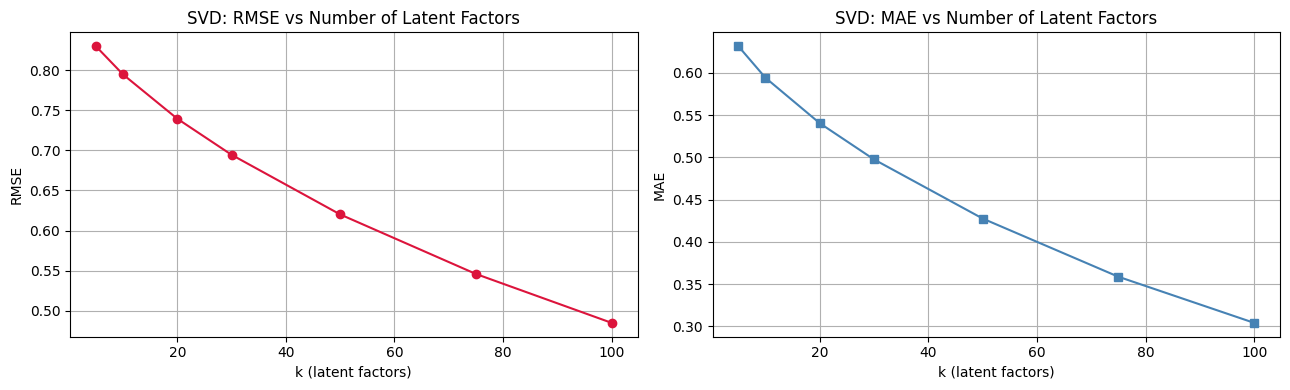

In [ ]:
k_values = [5, 10, 20, 30, 50, 75, 100]
rmse_list, mae_list = [], []

for k in k_values:
    if k >= min(R.shape):
        rmse_list.append(np.nan)
        mae_list.append(np.nan)
        continue
    svd_k = TruncatedSVD(n_components=k, random_state=42)
    U_tmp = svd_k.fit_transform(R)
    Vt_tmp = svd_k.components_
    R_rec = np.dot(U_tmp, Vt_tmp) + user_means.values.reshape(-1, 1)
    R_rec = np.clip(R_rec, 0.5, 5.0)
    pred_df = pd.DataFrame(R_rec, index=user_item_matrix.index, columns=user_item_matrix.columns)
    pv = pred_df.values[mask]
    rmse_list.append(np.sqrt(mean_squared_error(actual_vals, pv)))
    mae_list.append(mean_absolute_error(actual_vals, pv))
    print(f"k={k:3d} → RMSE={rmse_list[-1]:.4f}, MAE={mae_list[-1]:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_values, rmse_list, 'o-', color='crimson')
axes[0].set_title('SVD: RMSE vs Number of Latent Factors')
axes[0].set_xlabel('k (latent factors)')
axes[0].set_ylabel('RMSE')
axes[0].grid(True)

axes[1].plot(k_values, mae_list, 's-', color='steelblue')
axes[1].set_title('SVD: MAE vs Number of Latent Factors')
axes[1].set_xlabel('k (latent factors)')
axes[1].set_ylabel('MAE')
axes[1].grid(True)

plt.tight_layout()
plt.show()

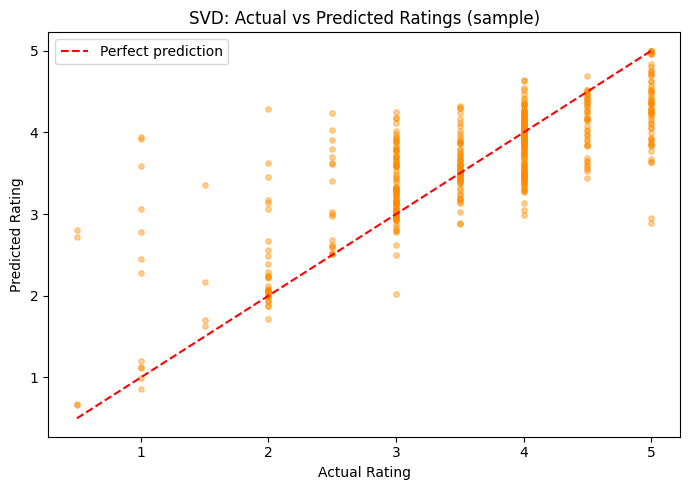

In [13]:
sample_idx = np.random.choice(len(actual_vals), size=500, replace=False)
plt.figure(figsize=(7, 5))
plt.scatter(actual_vals[sample_idx], predicted_vals[sample_idx], alpha=0.4, s=15, color='darkorange')
plt.plot([0.5, 5], [0.5, 5], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('SVD: Actual vs Predicted Ratings (sample)')
plt.legend()
plt.tight_layout()
plt.show()

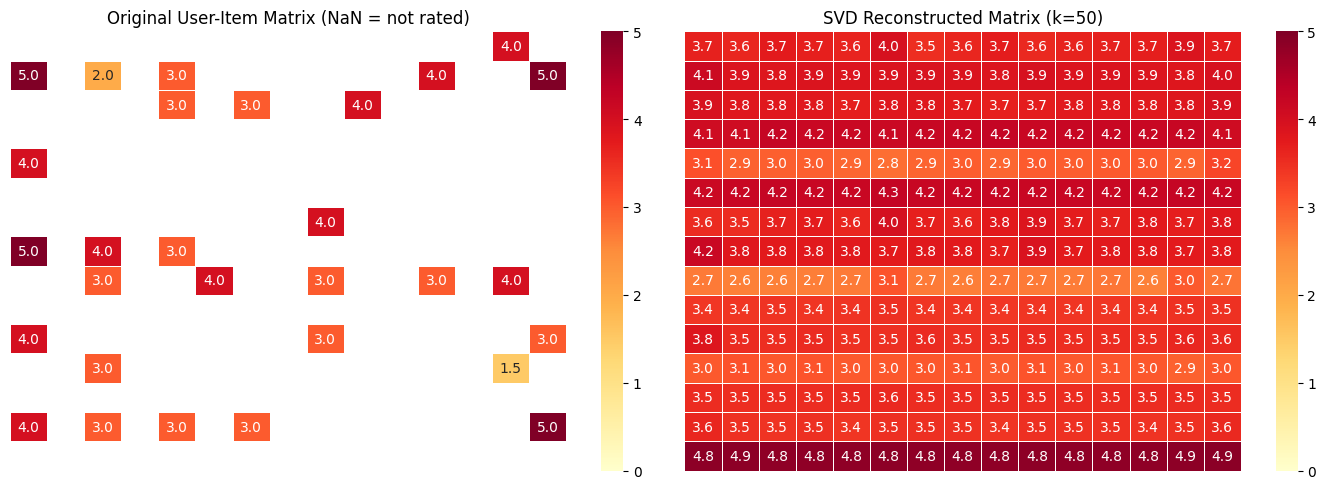

In [ ]:
n_show = 15
orig_slice  = user_item_matrix.iloc[:n_show, :n_show].values.astype(float)
pred_slice  = predicted_df.iloc[:n_show,  :n_show].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(orig_slice, ax=axes[0], cmap='YlOrRd', vmin=0, vmax=5,
            annot=True, fmt='.1f', linewidths=0.5,
            xticklabels=False, yticklabels=False,
            mask=np.isnan(orig_slice))
axes[0].set_title('Original User-Item Matrix (NaN = not rated)')

sns.heatmap(pred_slice, ax=axes[1], cmap='YlOrRd', vmin=0, vmax=5,
            annot=True, fmt='.1f', linewidths=0.5,
            xticklabels=False, yticklabels=False)
axes[1].set_title(f'SVD Reconstructed Matrix (k={K})')

plt.tight_layout()
plt.show()

In [ ]:
def get_svd_recommendations(user_id, predicted_df, user_item_matrix, movies_df, top_n=10):
    """Return top-N unseen movie recommendations for a user."""
    if user_id not in predicted_df.index:
        print(f"User {user_id} not found.")
        return pd.DataFrame()

    # Movies already rated by this user
    rated_movies = user_item_matrix.loc[user_id].dropna().index.tolist()

    # Predicted scores for unseen movies
    user_preds = predicted_df.loc[user_id].copy()
    user_preds = user_preds.drop(index=rated_movies, errors='ignore')
    top_movies = user_preds.sort_values(ascending=False).head(top_n)

    recs = movies_df[movies_df['movieId'].isin(top_movies.index)].copy()
    recs['predicted_rating'] = recs['movieId'].map(top_movies).round(2)
    return recs[['movieId','title','genres','predicted_rating']].sort_values('predicted_rating', ascending=False)

sample_user = user_item_matrix.index[0]
print(f"Top-10 SVD recommendations for User {sample_user}:")
recs_svd = get_svd_recommendations(sample_user, predicted_df, user_item_matrix, movies)
display(recs_svd)

Top-10 SVD recommendations for User 1:


,movieId,title,genres,predicted_rating
744,923,Citizen Kane (1941),Drama|Mystery,4.00
3322,4226,Memento (2000),Mystery|Thriller,4.00
975,1214,Alien (1979),Horror|Sci-Fi,3.97
745,924,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi,3.97
1843,2329,American History X (1998),Crime|Drama,3.96
5,6,Heat (1995),Action|Crime|Thriller,3.95
7669,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,3.95
2519,3147,"Green Mile, The (1999)",Crime|Drama,3.92
962,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi,3.91
4435,5903,Equilibrium (2002),Action|Sci-Fi|Thriller,3.91


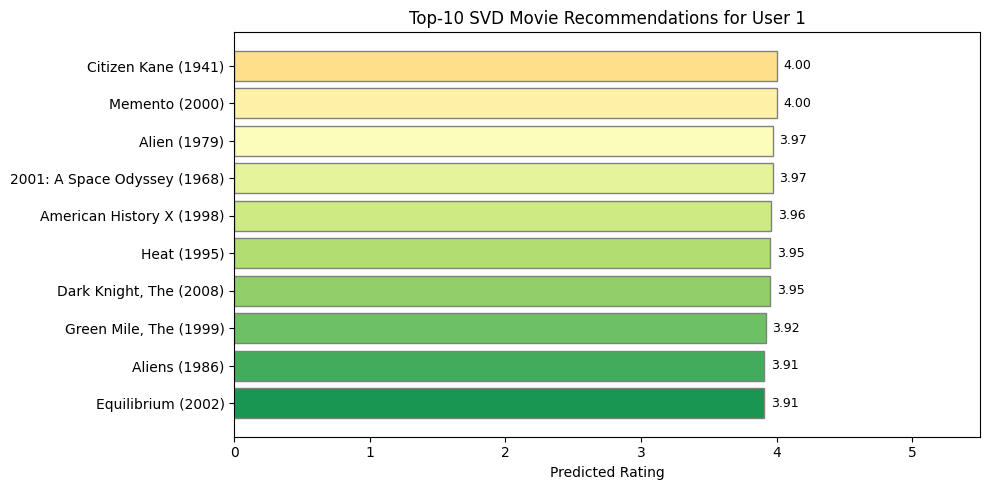

In [16]:
if not recs_svd.empty:
    plt.figure(figsize=(10, 5))
    colors = plt.cm.RdYlGn(np.linspace(0.4, 0.9, len(recs_svd)))
    bars = plt.barh(recs_svd['title'].str[:40], recs_svd['predicted_rating'], color=colors, edgecolor='grey')
    plt.xlabel('Predicted Rating')
    plt.title(f'Top-10 SVD Movie Recommendations for User {sample_user}')
    plt.xlim(0, 5.5)
    for bar, val in zip(bars, recs_svd['predicted_rating']):
        plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

---
# SCENARIO 2 – Matrix Factorization using NMF

In [ ]:
print(f"Users: {user_item_matrix.shape[0]}, Movies: {user_item_matrix.shape[1]}")
display(user_item_matrix.iloc[:5, :8])

Reusing filtered ratings from Scenario 1.
Users: 668, Movies: 2315


movieId,1,2,3,4,5,6,7,9
userId,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,NaN,2.0,NaN,3.0,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,3.0,NaN,3.0,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
R_nmf = user_item_matrix.fillna(0).values

print("Matrix filled with 0 for NMF (NaN positions treated as unobserved).")
print(f"Matrix shape: {R_nmf.shape}")
print(f"Min value: {R_nmf.min()}, Max value: {R_nmf.max()}")

Matrix filled with 0 for NMF (NaN positions treated as unobserved).
Matrix shape: (668, 2315)
Min value: 0.0, Max value: 5.0


In [ ]:
K_NMF = 50  # number of latent features

nmf = NMF(
    n_components=K_NMF,
    init='nndsvda',
    random_state=42,
    max_iter=300,
    tol=1e-4
)

W = nmf.fit_transform(R_nmf)   
H = nmf.components_            

print(f"NMF applied with k={K_NMF} latent features")
print(f"W (User-feature matrix) shape : {W.shape}")
print(f"H (Item-feature matrix) shape : {H.shape}")
print(f"Reconstruction error (Frobenius norm): {nmf.reconstruction_err_:.4f}")

NMF applied with k=50 latent features
W (User-feature matrix) shape : (668, 50)
H (Item-feature matrix) shape : (50, 2315)
Reconstruction error (Frobenius norm): 735.3640


In [20]:
R_nmf_reconstructed = np.dot(W, H)
R_nmf_reconstructed = np.clip(R_nmf_reconstructed, 0.5, 5.0)

predicted_nmf_df = pd.DataFrame(
    R_nmf_reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

print("NMF Reconstructed matrix (sample):")
display(predicted_nmf_df.iloc[:5, :8].round(2))

NMF Reconstructed matrix (sample):


movieId,1,2,3,4,5,6,7,9
userId,,,,,,,,
1,2.99,0.5,0.50,0.5,0.50,1.05,0.50,0.5
2,2.94,0.5,1.83,0.5,1.55,2.02,1.19,0.9
3,0.61,1.2,0.62,0.5,0.61,0.50,0.63,0.5
4,0.50,0.5,0.50,0.5,0.50,0.50,0.50,0.5
5,0.93,0.5,0.50,0.5,0.50,0.50,0.50,0.5


In [ ]:
nmf_pred_vals = predicted_nmf_df.values[mask]
rmse_nmf = np.sqrt(mean_squared_error(actual_vals, nmf_pred_vals))
mae_nmf  = mean_absolute_error(actual_vals, nmf_pred_vals)

print(f"NMF (k={K_NMF}) Evaluation")
print(f"  RMSE : {rmse_nmf:.4f}")
print(f"  MAE  : {mae_nmf:.4f}")

NMF (k=50) Evaluation
  RMSE : 2.1483
  MAE  : 1.6764


In [ ]:
def precision_recall_at_k(predicted_df, user_item_matrix, k=10, threshold=3.5):
    """Compute Precision@K and Recall@K averaged over all users."""
    precisions, recalls = [], []

    for user_id in user_item_matrix.index:
        actual = user_item_matrix.loc[user_id].dropna()
        relevant = set(actual[actual >= threshold].index)
        if not relevant:
            continue

        preds = predicted_df.loc[user_id].drop(index=actual.index, errors='ignore')
        top_k = set(preds.nlargest(k).index)

        hit = len(top_k & relevant)
        precisions.append(hit / k)
        recalls.append(hit / len(relevant) if relevant else 0)

    return np.mean(precisions), np.mean(recalls)

prec_nmf, rec_nmf = precision_recall_at_k(predicted_nmf_df, user_item_matrix, k=10)
prec_svd, rec_svd = precision_recall_at_k(predicted_df,     user_item_matrix, k=10)

print("Precision@10 / Recall@10:")
print(f"  SVD  →  Precision: {prec_svd:.4f} | Recall: {rec_svd:.4f}")
print(f"  NMF  →  Precision: {prec_nmf:.4f} | Recall: {rec_nmf:.4f}")

Precision@10 / Recall@10:
  SVD  →  Precision: 0.0000 | Recall: 0.0000
  NMF  →  Precision: 0.0000 | Recall: 0.0000


In [23]:
def get_nmf_recommendations(user_id, predicted_nmf_df, user_item_matrix, movies_df, top_n=10):
    if user_id not in predicted_nmf_df.index:
        print(f"User {user_id} not found.")
        return pd.DataFrame()
    rated_movies = user_item_matrix.loc[user_id].dropna().index.tolist()
    user_preds = predicted_nmf_df.loc[user_id].drop(index=rated_movies, errors='ignore')
    top_movies = user_preds.sort_values(ascending=False).head(top_n)
    recs = movies_df[movies_df['movieId'].isin(top_movies.index)].copy()
    recs['predicted_rating'] = recs['movieId'].map(top_movies).round(2)
    return recs[['movieId','title','genres','predicted_rating']].sort_values('predicted_rating', ascending=False)

print(f"Top-10 NMF recommendations for User {sample_user}:")
recs_nmf = get_nmf_recommendations(sample_user, predicted_nmf_df, user_item_matrix, movies)
display(recs_nmf)

Top-10 NMF recommendations for User 1:


,movieId,title,genres,predicted_rating
1050,1291,Indiana Jones and the Last Crusade (1989),Action|Adventure,3.04
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2.99
959,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,2.18
7669,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,2.12
1843,2329,American History X (1998),Crime|Drama,1.97
2999,3793,X-Men (2000),Action|Adventure|Sci-Fi,1.91
3322,4226,Memento (2000),Mystery|Thriller,1.88
4802,6539,Pirates of the Caribbean: The Curse of the Bla...,Action|Adventure|Comedy|Fantasy,1.78
1360,1704,Good Will Hunting (1997),Drama|Romance,1.73
1232,1527,"Fifth Element, The (1997)",Action|Adventure|Comedy|Sci-Fi,1.55


k=  5 → RMSE=2.6110, MAE=2.3264
k= 10 → RMSE=2.4933, MAE=2.1939
k= 20 → RMSE=2.3703, MAE=2.0293
k= 30 → RMSE=2.2873, MAE=1.9046
k= 50 → RMSE=2.1502, MAE=1.6773
k= 75 → RMSE=1.9992, MAE=1.4552


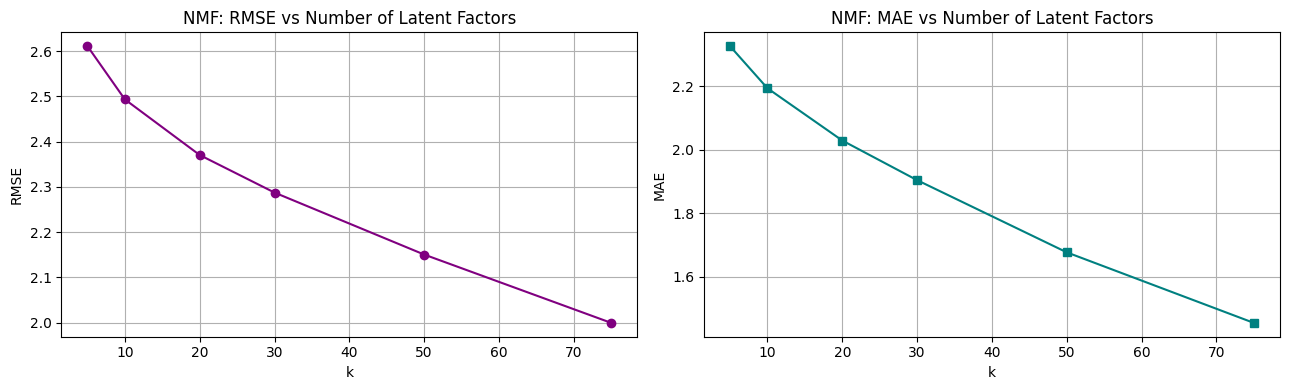

In [24]:
k_values_nmf = [5, 10, 20, 30, 50, 75]
rmse_nmf_list, mae_nmf_list = [], []

for k in k_values_nmf:
    nmf_k = NMF(n_components=k, init='nndsvda', random_state=42, max_iter=200)
    W_k = nmf_k.fit_transform(R_nmf)
    R_rec = np.clip(np.dot(W_k, nmf_k.components_), 0.5, 5.0)
    pred_df_k = pd.DataFrame(R_rec, index=user_item_matrix.index, columns=user_item_matrix.columns)
    pv = pred_df_k.values[mask]
    rmse_nmf_list.append(np.sqrt(mean_squared_error(actual_vals, pv)))
    mae_nmf_list.append(mean_absolute_error(actual_vals, pv))
    print(f"k={k:3d} → RMSE={rmse_nmf_list[-1]:.4f}, MAE={mae_nmf_list[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_values_nmf, rmse_nmf_list, 'o-', color='purple')
axes[0].set_title('NMF: RMSE vs Number of Latent Factors')
axes[0].set_xlabel('k'); axes[0].set_ylabel('RMSE'); axes[0].grid(True)
axes[1].plot(k_values_nmf, mae_nmf_list, 's-', color='teal')
axes[1].set_title('NMF: MAE vs Number of Latent Factors')
axes[1].set_xlabel('k'); axes[1].set_ylabel('MAE'); axes[1].grid(True)
plt.tight_layout(); plt.show()

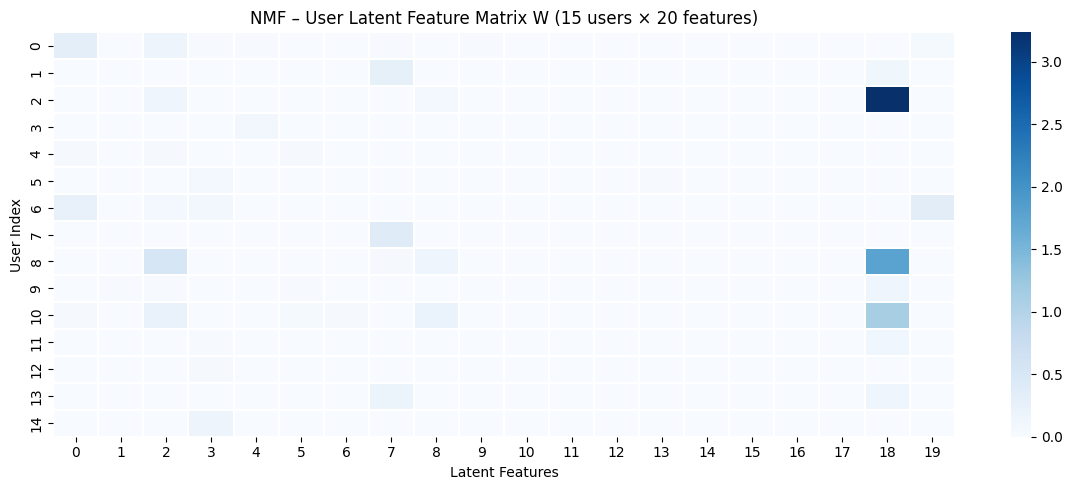

In [ ]:
plt.figure(figsize=(12, 5))
sns.heatmap(W[:15, :20], cmap='Blues', annot=False, linewidths=0.3)
plt.title('NMF – User Latent Feature Matrix W (15 users × 20 features)')
plt.xlabel('Latent Features')
plt.ylabel('User Index')
plt.tight_layout()
plt.show()

=== SVD vs NMF Comparison ===


,Method,k,RMSE,MAE,Precision@10,Recall@10
0,SVD,50,0.6201,0.4275,0.0,0.0
1,NMF,50,2.1483,1.6764,0.0,0.0


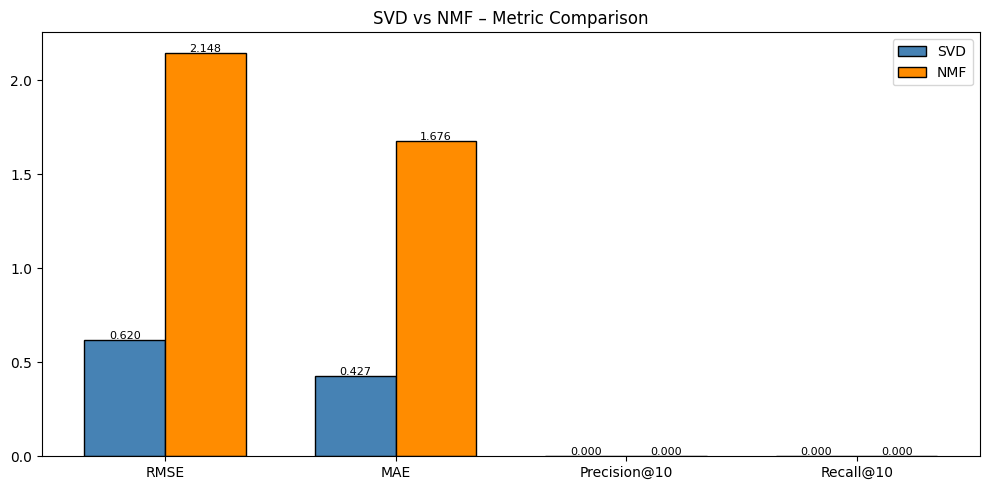

In [ ]:
comparison_df = pd.DataFrame({
    'Method'       : ['SVD', 'NMF'],
    'k'            : [K, K_NMF],
    'RMSE'         : [round(rmse_svd, 4), round(rmse_nmf, 4)],
    'MAE'          : [round(mae_svd,  4), round(mae_nmf,  4)],
    'Precision@10' : [round(prec_svd, 4), round(prec_nmf, 4)],
    'Recall@10'    : [round(rec_svd,  4), round(rec_nmf,  4)],
})
print("=== SVD vs NMF Comparison ===")
display(comparison_df)

metrics = ['RMSE', 'MAE', 'Precision@10', 'Recall@10']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comparison_df.loc[0, metrics], width, label='SVD', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df.loc[1, metrics], width, label='NMF', color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('SVD vs NMF – Metric Comparison')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

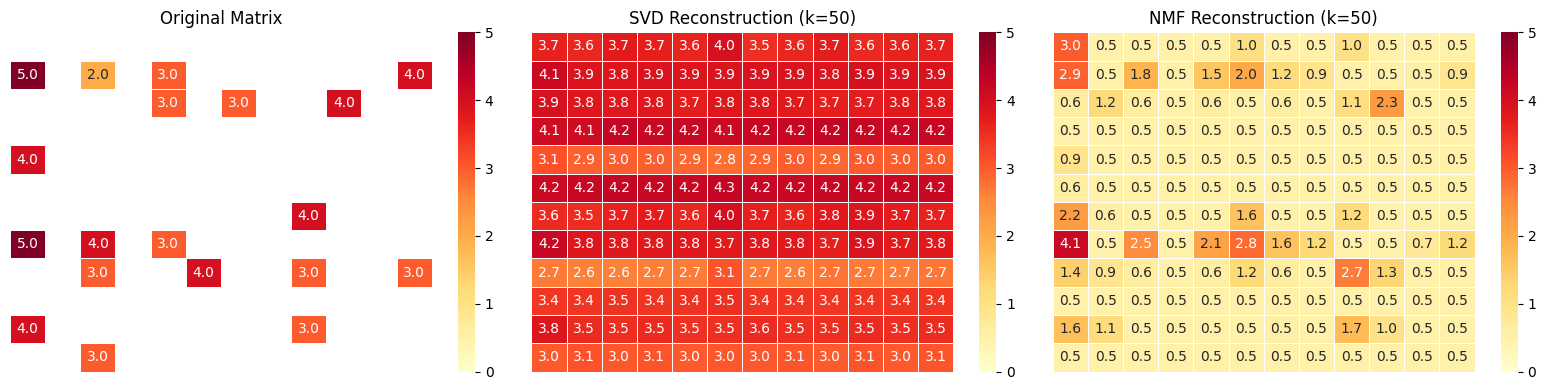

In [27]:
n_show = 12
orig_s = user_item_matrix.iloc[:n_show, :n_show].values.astype(float)
svd_s  = predicted_df.iloc[:n_show, :n_show].values
nmf_s  = predicted_nmf_df.iloc[:n_show, :n_show].values

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kws = dict(cmap='YlOrRd', vmin=0, vmax=5, annot=True, fmt='.1f',
           linewidths=0.4, xticklabels=False, yticklabels=False)

sns.heatmap(orig_s, ax=axes[0], **kws, mask=np.isnan(orig_s))
axes[0].set_title('Original Matrix')

sns.heatmap(svd_s, ax=axes[1], **kws)
axes[1].set_title(f'SVD Reconstruction (k={K})')

sns.heatmap(nmf_s, ax=axes[2], **kws)
axes[2].set_title(f'NMF Reconstruction (k={K_NMF})')

plt.tight_layout()
plt.show()

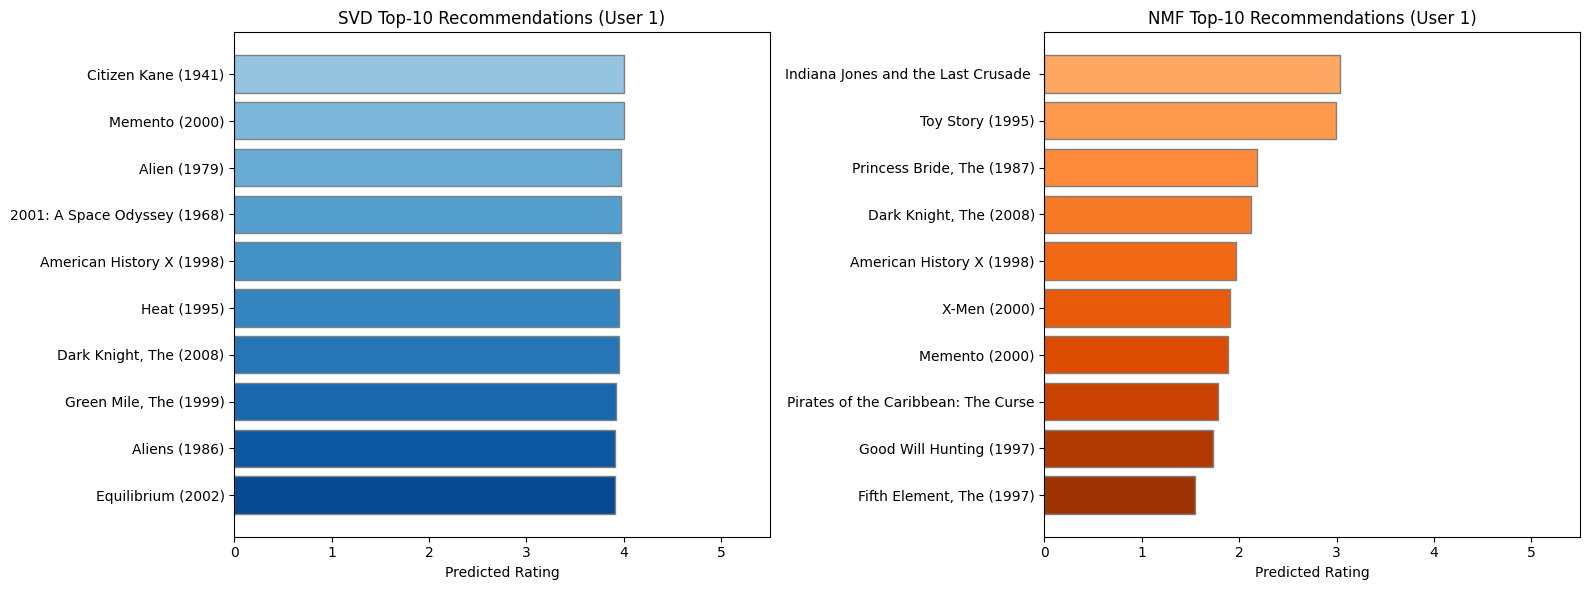

In [28]:
if not recs_svd.empty and not recs_nmf.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # SVD
    colors_svd = plt.cm.Blues(np.linspace(0.4, 0.9, len(recs_svd)))
    axes[0].barh(recs_svd['title'].str[:35], recs_svd['predicted_rating'], color=colors_svd, edgecolor='grey')
    axes[0].set_xlabel('Predicted Rating')
    axes[0].set_title(f'SVD Top-10 Recommendations (User {sample_user})')
    axes[0].set_xlim(0, 5.5)
    axes[0].invert_yaxis()

    # NMF
    colors_nmf = plt.cm.Oranges(np.linspace(0.4, 0.9, len(recs_nmf)))
    axes[1].barh(recs_nmf['title'].str[:35], recs_nmf['predicted_rating'], color=colors_nmf, edgecolor='grey')
    axes[1].set_xlabel('Predicted Rating')
    axes[1].set_title(f'NMF Top-10 Recommendations (User {sample_user})')
    axes[1].set_xlim(0, 5.5)
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()